In [4]:
import numpy as np
np.random.seed(62)

In [5]:
X=np.linspace(0,10,50).reshape(-1,1)
print(X)

[[ 0.        ]
 [ 0.20408163]
 [ 0.40816327]
 [ 0.6122449 ]
 [ 0.81632653]
 [ 1.02040816]
 [ 1.2244898 ]
 [ 1.42857143]
 [ 1.63265306]
 [ 1.83673469]
 [ 2.04081633]
 [ 2.24489796]
 [ 2.44897959]
 [ 2.65306122]
 [ 2.85714286]
 [ 3.06122449]
 [ 3.26530612]
 [ 3.46938776]
 [ 3.67346939]
 [ 3.87755102]
 [ 4.08163265]
 [ 4.28571429]
 [ 4.48979592]
 [ 4.69387755]
 [ 4.89795918]
 [ 5.10204082]
 [ 5.30612245]
 [ 5.51020408]
 [ 5.71428571]
 [ 5.91836735]
 [ 6.12244898]
 [ 6.32653061]
 [ 6.53061224]
 [ 6.73469388]
 [ 6.93877551]
 [ 7.14285714]
 [ 7.34693878]
 [ 7.55102041]
 [ 7.75510204]
 [ 7.95918367]
 [ 8.16326531]
 [ 8.36734694]
 [ 8.57142857]
 [ 8.7755102 ]
 [ 8.97959184]
 [ 9.18367347]
 [ 9.3877551 ]
 [ 9.59183673]
 [ 9.79591837]
 [10.        ]]


In [ ]:
noise=np.random.normal(0,0.2,size=(50,1))
y=np.log(X+1)+noise

In [7]:
hidden_units=3

In [8]:
W1=np.random.uniform(-1,1,size=(1,hidden_units))
b1=np.zeros((1,hidden_units))
W2=np.random.uniform(-1,1,size=(hidden_units,1))
b2=np.zeros((1,1))

In [9]:
def activation(z):
    return np.maximum(0,z)

def activation_slope(z):
    return (z>0).astype(float)


In [10]:
learning_rate=0.01
epochs=1000

for epoch in range(epochs):

    z1=X@W1+b1
    h=activation(z1)
    y_hat=h@W2+b2

    error=y_hat-y
    loss=np.mean(error**2)

    dL_dy=2*error/len(X)

    dL_dW2=h.T@dL_dy
    dL_db2=np.sum(dL_dy,axis=0,keepdims=True)

    dL_dh=dL_dy@W2.T
    dL_dz1=dL_dh*activation_slope(z1)

    dL_dW1=X.T@dL_dz1
    dL_db1=np.sum(dL_dz1,axis=0,keepdims=True)

    W1-=learning_rate*dL_dW1
    b1-=learning_rate*dL_db1
    W2-=learning_rate*dL_dW2
    b2-=learning_rate*dL_db2

    if epoch%100==0:
        print("Epoch:",epoch,"Loss:",loss)

Epoch: 0 Loss: 0.21396192503459496
Epoch: 100 Loss: 0.07375357810442738
Epoch: 200 Loss: 0.059018262923595834
Epoch: 300 Loss: 0.0549913185648577
Epoch: 400 Loss: 0.05353245664594414
Epoch: 500 Loss: 0.05260355276013617
Epoch: 600 Loss: 0.05178921279927531
Epoch: 700 Loss: 0.05102471222538139
Epoch: 800 Loss: 0.05025757468458983
Epoch: 900 Loss: 0.04948411468927492


In [12]:
print(f'Final Training Loss (MSE): {loss:.6f}')
print(f'Final RMSE: {np.sqrt(loss):.6f}')

z1_final = X @ W1 + b1
h_final  = activation(z1_final)
y_pred   = h_final @ W2 + b2

print('\nSample Predictions (first 10 rows):')
print(f'{"X":>8}  {"Actual y":>10}  {"Predicted":>10}  {"Error":>10}')
for i in range(10):
    print(f'{X[i,0]:8.4f}  {y[i,0]:10.4f}  {y_pred[i,0]:10.4f}  {y[i,0]-y_pred[i,0]:10.4f}')

Final Training Loss (MSE): 0.048714
Final RMSE: 0.220713

Sample Predictions (first 10 rows):
       X    Actual y   Predicted       Error
  0.0000     -0.0025      0.4557     -0.4582
  0.2041      0.0802      0.5134     -0.4332
  0.4082      0.2848      0.5711     -0.2863
  0.6122      0.7023      0.6288      0.0735
  0.8163      0.3124      0.6864     -0.3741
  1.0204      0.8821      0.7441      0.1380
  1.2245      0.4942      0.8018     -0.3076
  1.4286      0.9354      0.8595      0.0759
  1.6327      0.8396      0.9171     -0.0776
  1.8367      1.3611      0.9748      0.3863


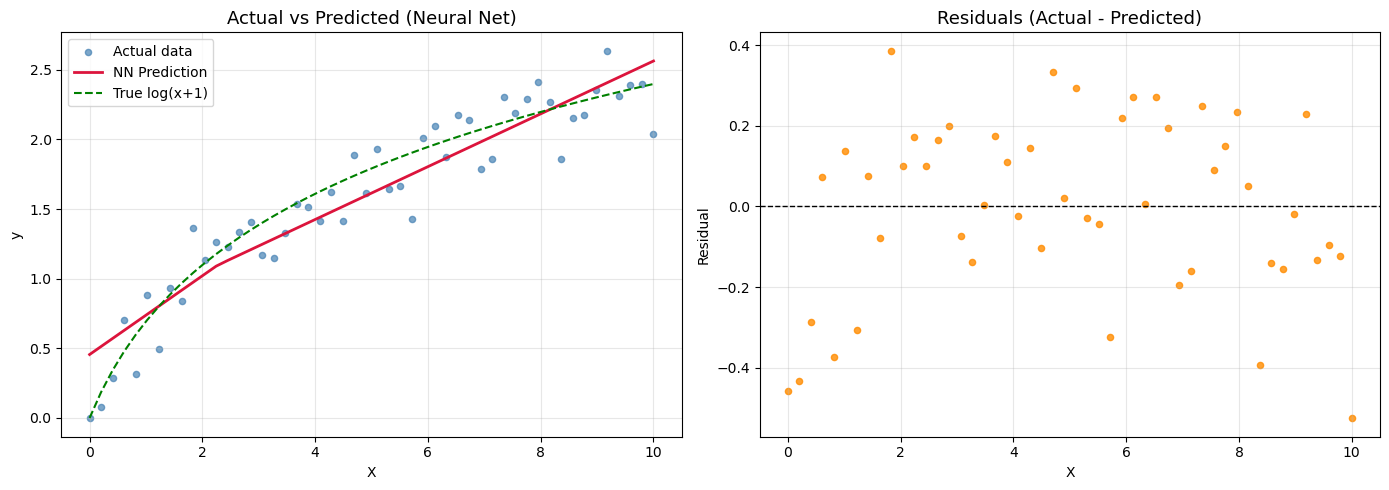

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(X, y, color='steelblue', s=20, label='Actual data', alpha=0.7)
axes[0].plot(X, y_pred, color='crimson', linewidth=2, label='NN Prediction')
axes[0].plot(X, np.log(X + 1), color='green', linewidth=1.5, linestyle='--', label='True log(x+1)')
axes[0].set_title('Actual vs Predicted (Neural Net)', fontsize=13)
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y - y_pred
axes[1].scatter(X, residuals, color='darkorange', s=20, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Residuals (Actual - Predicted)', fontsize=13)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print('── Learned Parameters ──')
print('W1 (input -> hidden):', W1)
print('b1 (hidden bias):    ', b1)
print('W2 (hidden -> output):', W2.T)
print('b2 (output bias):    ', b2)

ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot
print(f'\nR2 Score: {r2:.4f}')
print(f'The model explains {r2*100:.1f}% of the variance in y.')

── Learned Parameters ──
W1 (input -> hidden): [[ 0.15513116 -0.9215772   0.38089031]]
b1 (hidden bias):     [[-0.35176749  0.          0.2155644 ]]
W2 (hidden -> output): [[-0.5993097   0.81659206  0.741969  ]]
b2 (output bias):     [[0.29580091]]

R2 Score: 0.8850
The model explains 88.5% of the variance in y.
